# 📞 Telecom Customer Churn Prediction: ML for Consumer Protection & Market Competition

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting customer churn from telecom service usage to support consumer protection, retention analytics, and market competition policy  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting customer churn using service usage patterns, contract details, billing information, and customer demographics. The model supports **consumer retention analytics**, **regulatory market monitoring**, and **competition policy assessment**.

### Government Policy Context
- **ACCC** — Telecommunications competition monitoring, consumer switching behaviour, market concentration
- **ACMA** — Telecom consumer safeguards, complaint trends, carrier licence compliance
- **Department of Communications** — Universal Service Guarantee, NBN policy, regional connectivity
- **TIO (Telecommunications Industry Ombudsman)** — Complaint resolution, systemic issue identification
- **OAIC** — Customer data handling, Privacy Act compliance in telecom marketing

### Operational Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| High churn risk | Proactive retention offer, service review | Customer retention team |
| Moderate risk | Satisfaction survey, loyalty program enrolment | Account manager |
| Low risk (loyal) | Cross-sell/upsell opportunity, VIP recognition | Marketing team |
| Churning (confirmed) | Exit interview, win-back campaign after cooling-off | Retention analytics |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv') and data_path is None:
            data_path = full_path

if data_path is None:
    raise FileNotFoundError("No CSV found")

df = pd.read_csv(data_path)
print(f"\nUsing: {data_path}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


  Found: /kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv

Using: /kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv
Loaded: 7,043 rows x 21 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:25s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls:3d} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. customerID                | object     | unique= 7043 | nulls=  0 | eg: 7590-VHVEG
   1. gender                    | object     | unique=    2 | nulls=  0 | eg: Female
   2. SeniorCitizen             | int64      | unique=    2 | nulls=  0 | eg: 0
   3. Partner                   | object     | unique=    2 | nulls=  0 | eg: Yes
   4. Dependents                | object     | unique=    2 | nulls=  0 | eg: No
   5. tenure                    | int64      | unique=   73 | nulls=  0 | eg: 1
   6. PhoneService              | object     | unique=    2 | nulls=  0 | eg: No
   7. MultipleLines             | object     | unique=    3 | nulls=  0 | eg: No phone service
   8. InternetService           | object     | unique=    3 | nulls=  0 | eg: DSL
   9. OnlineSecurity            | object     | unique=    3 | nulls=  0 | eg: No
  10. OnlineBackup              | object     | unique=    3 | nulls=  0 | eg: Yes
  11. DeviceProtection          | object     | unique=    3 | nulls

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Target Variable Analysis

In [4]:
target_candidates = ['Churn', 'churn', 'CHURN', 'target', 'Target', 'class', 'Class',
                     'label', 'Label', 'Exited', 'churned']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target")

print(f"\nRaw values:")
print(df[target_col].value_counts())

if df[target_col].dtype == 'object':
    churn_kw = ['Yes', 'yes', 'True', 'true', '1', 'Churn', 'churned']
    mapping = {v: (1 if v in churn_kw else 0) for v in df[target_col].unique()}
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapped (1=Churned, 0=Retained): {mapping}")

df[target_col] = df[target_col].astype(int)
print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
assert df[target_col].nunique() >= 2
imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")


Found target: 'Churn'

Raw values:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Mapped (1=Churned, 0=Retained): {'No': 0, 'Yes': 1}

Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Imbalance ratio: 0.361


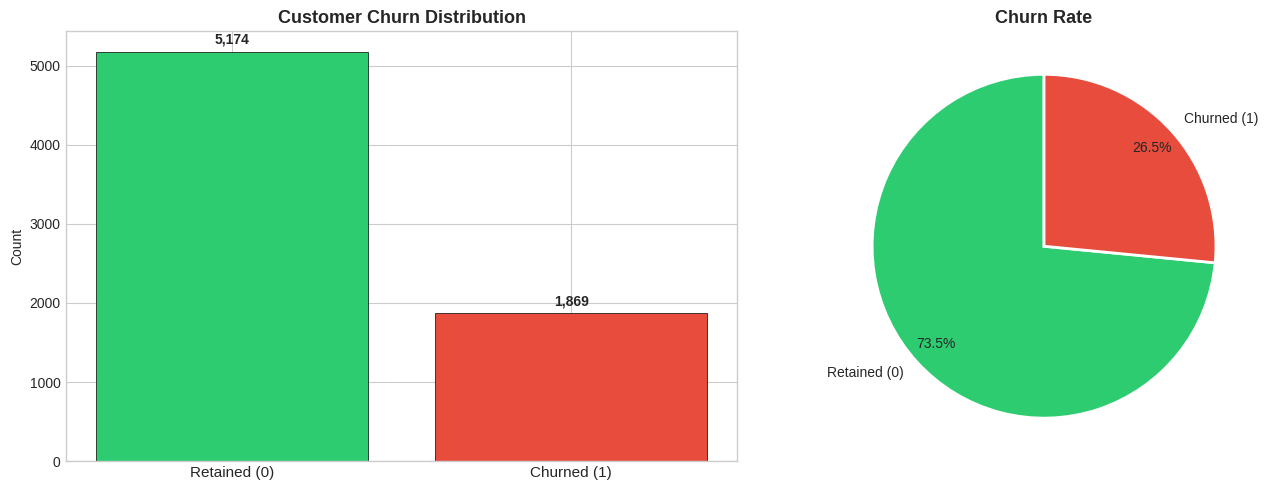

AU context: Australian telecom market has 4 major carriers (Telstra, Optus, TPG, Vocus).
TIO received ~119,000 complaints in 2022-23. ACCC monitors switching barriers.
Customer acquisition costs 5-7x retention costs — churn prevention is critical.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
labels = ['Retained (0)', 'Churned (1)']
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(range(2), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(2)); axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('Customer Churn Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + max(vc.values)*0.02, f'{v:,}', ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: Australian telecom market has 4 major carriers (Telstra, Optus, TPG, Vocus).")
print("TIO received ~119,000 complaints in 2022-23. ACCC monitors switching barriers.")
print("Customer acquisition costs 5-7x retention costs — churn prevention is critical.")


## 3. Exploratory Data Analysis

Key questions for telecom regulation:
- Which service features drive customer churn?
- Do contract types (month-to-month vs lock-in) affect churn?
- Are billing issues (charges, payment method) correlated with churn?
- Do bundled services (internet, phone, streaming) reduce churn?


Converted TotalCharges to numeric (11 NaN created)
Numeric features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


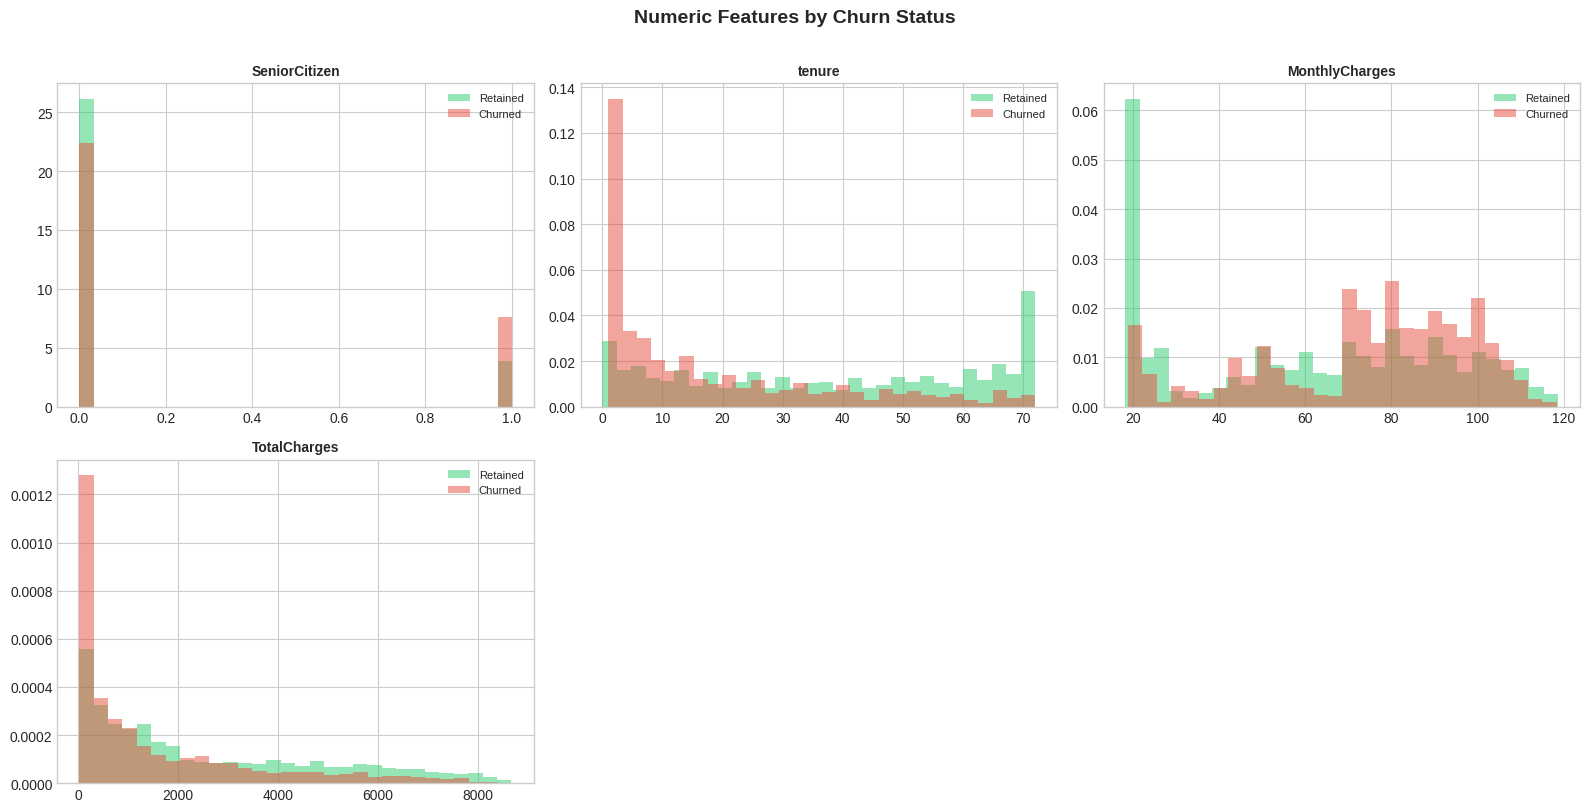

In [6]:
# Fix TotalCharges if it's stored as string
if 'TotalCharges' in df.columns and df['TotalCharges'].dtype == 'object':
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    print(f"Converted TotalCharges to numeric ({df['TotalCharges'].isnull().sum()} NaN created)")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
numeric_cols = [c for c in numeric_cols if c.lower() not in ['customerid', 'id']]
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

plot_cols = numeric_cols[:6]
if len(plot_cols) > 0:
    n_rows_p = max(1, (len(plot_cols) + 2) // 3)
    fig, axes = plt.subplots(n_rows_p, 3, figsize=(16, 4 * n_rows_p))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Retained', 'Churned']):
            subset = df[df[target_col] == label][col].dropna()
            if len(subset) > 0:
                axes[i].hist(subset, bins=30, alpha=0.5, label=name, density=True, color=color)
        axes[i].set_title(col, fontsize=10, fontweight='bold'); axes[i].legend(fontsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Numeric Features by Churn Status', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


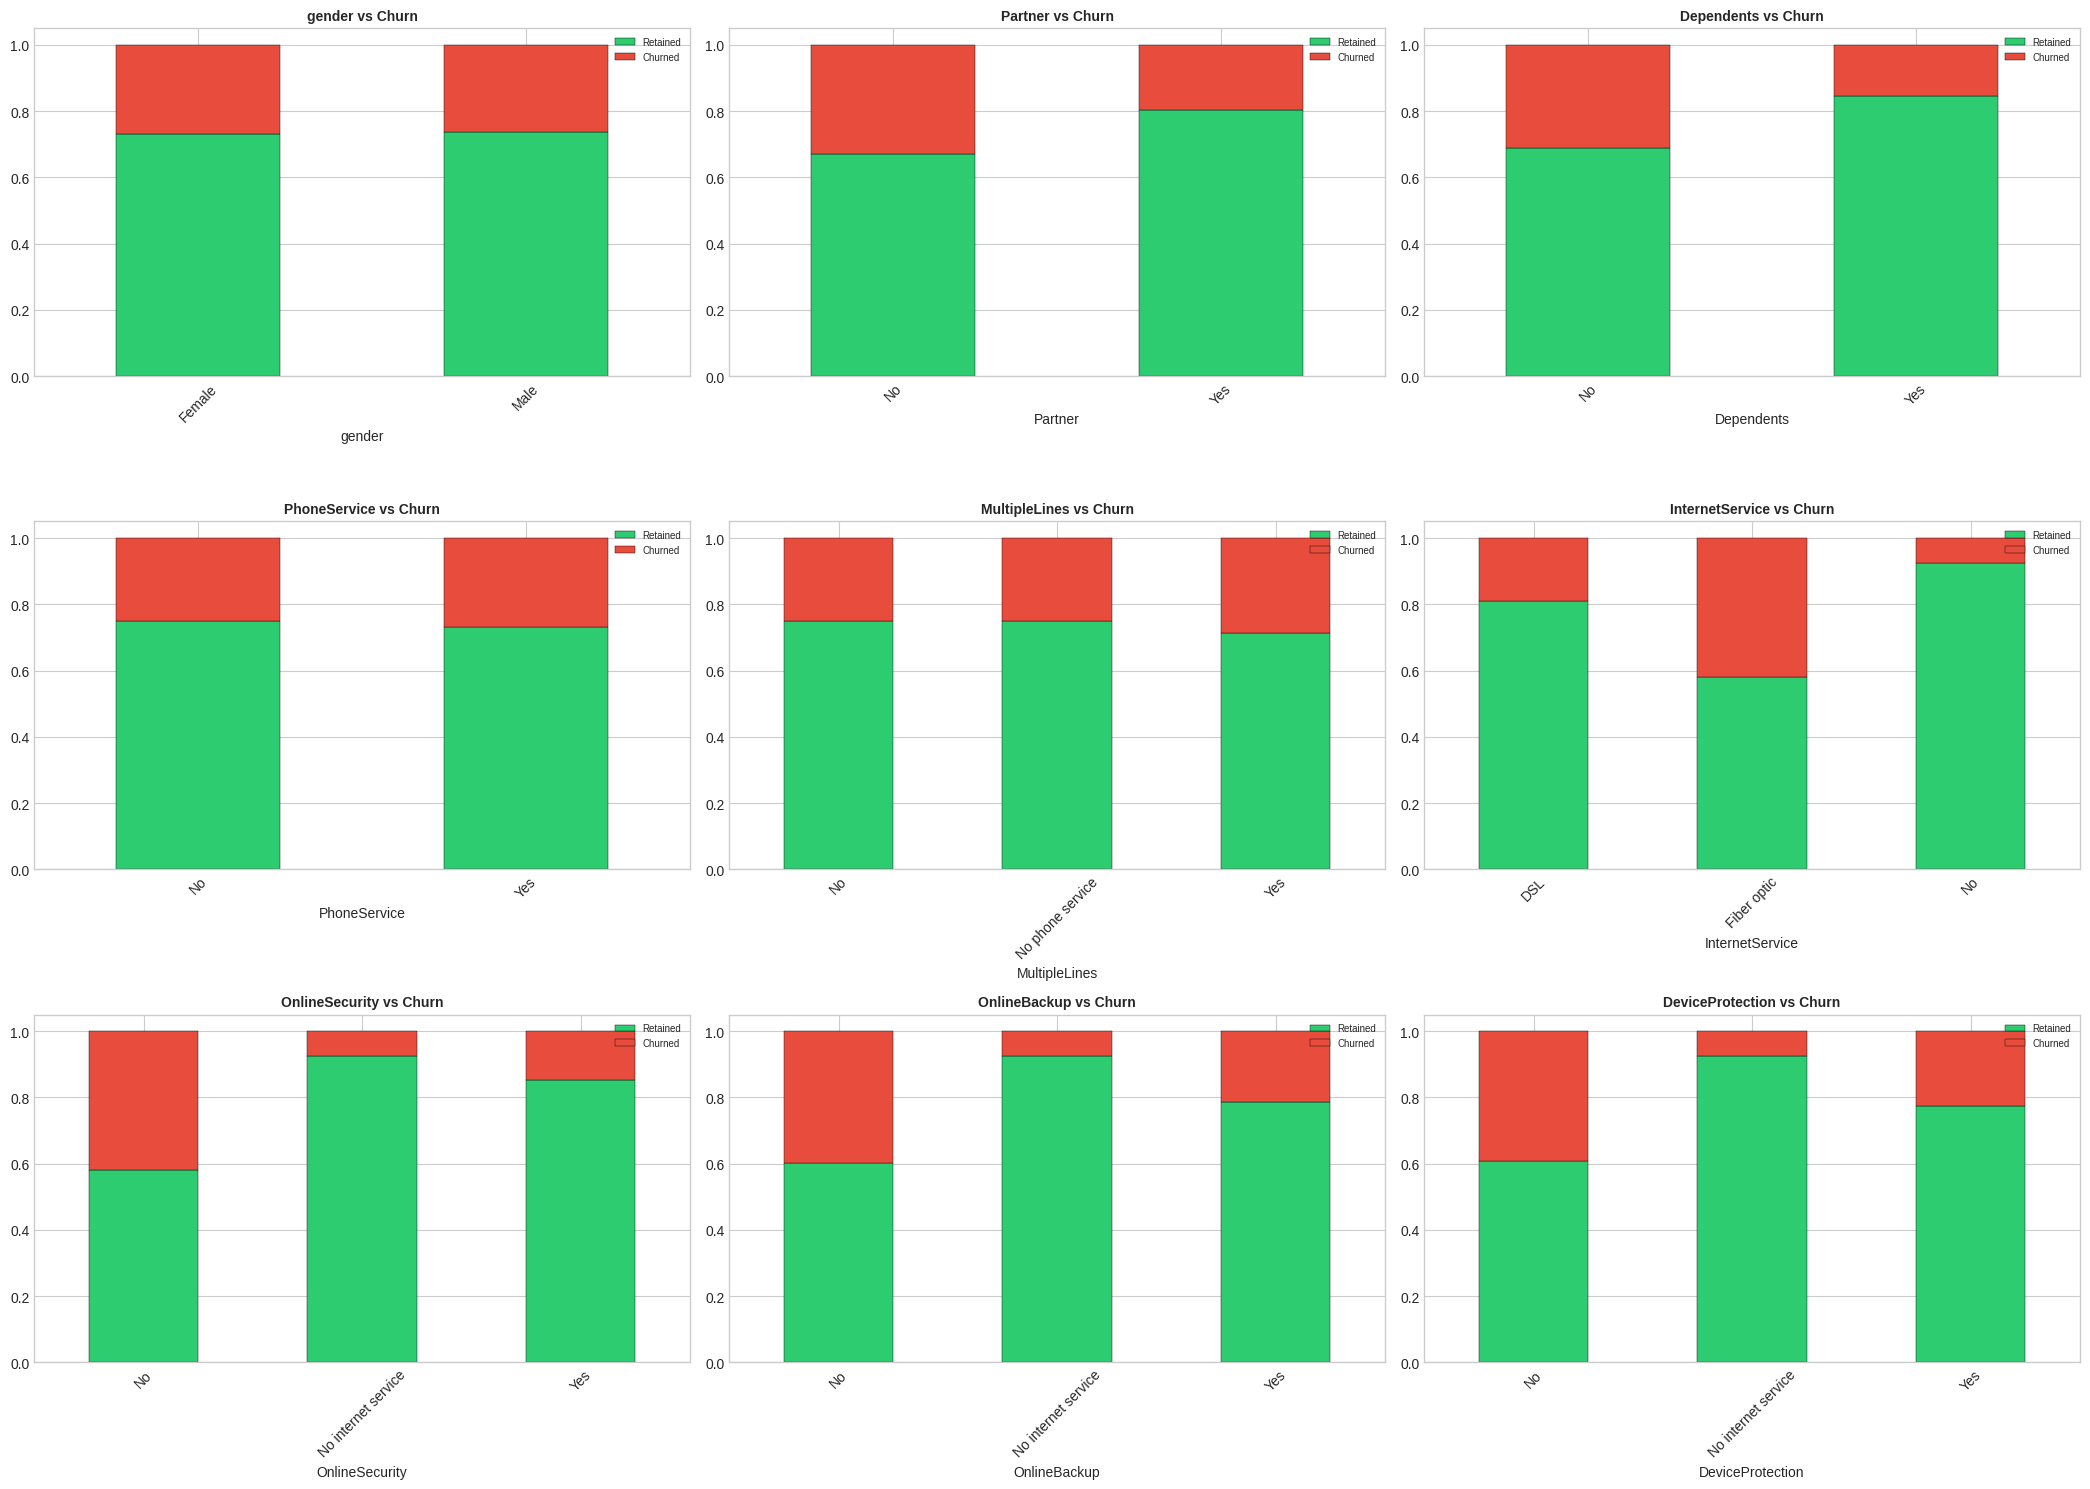

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 10 and 'id' not in c.lower()]
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

if len(cat_cols) > 0:
    plot_cats = cat_cols[:9]
    n_cols_p = min(3, len(plot_cats))
    n_rows_p = max(1, (len(plot_cats) + n_cols_p - 1) // n_cols_p)
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(7 * n_cols_p, 5 * n_rows_p))
    if isinstance(axes, np.ndarray): axes = axes.flatten()
    else: axes = [axes]
    for i, col in enumerate(plot_cats):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'],
                edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs Churn', fontsize=10, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(['Retained', 'Churned'], fontsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


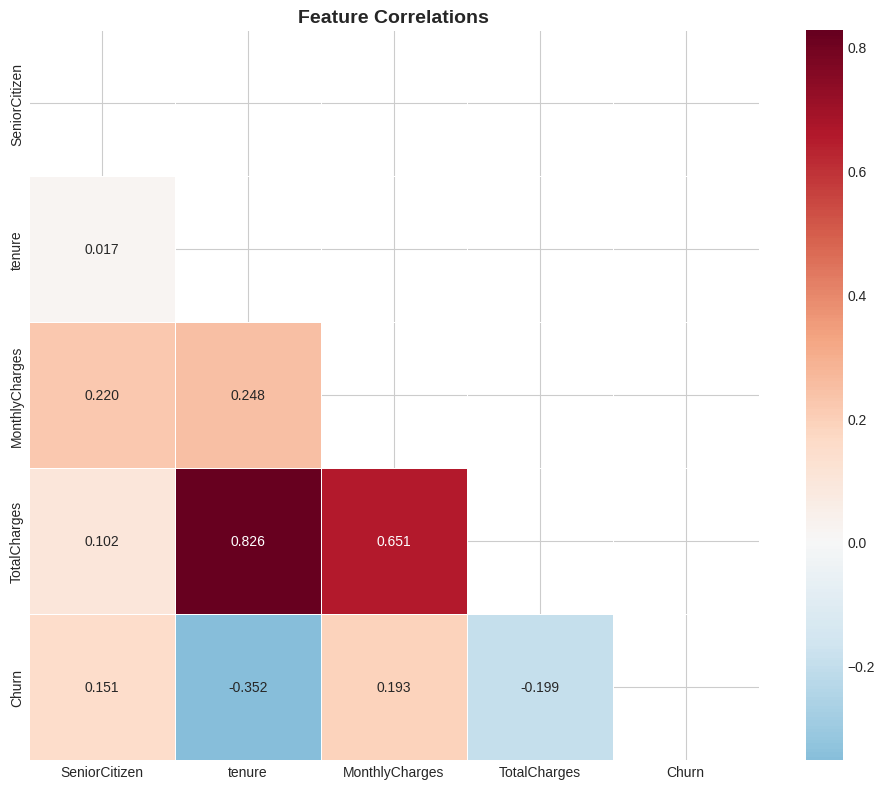

In [8]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols + [target_col]].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()


## 4. Feature Engineering & Preprocessing

In [9]:
df_model = df.copy()

# Drop ID columns
drop_cols = [c for c in df_model.columns if c.lower() in ['customerid', 'id', 'index', 'unnamed: 0']]
if drop_cols:
    df_model.drop(columns=drop_cols, inplace=True)
    print(f"Dropped: {drop_cols}")

# Fix TotalCharges
if 'TotalCharges' in df_model.columns and df_model['TotalCharges'].dtype == 'object':
    df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce')

# Encode categoricals
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())

print(f"\nFeature matrix: {X.shape}")
print(f"Target: {dict(zip(*np.unique(y, return_counts=True)))}")


Dropped: ['customerID']
  Encoded 'gender': 2 classes
  Encoded 'Partner': 2 classes
  Encoded 'Dependents': 2 classes
  Encoded 'PhoneService': 2 classes
  Encoded 'MultipleLines': 3 classes
  Encoded 'InternetService': 3 classes
  Encoded 'OnlineSecurity': 3 classes
  Encoded 'OnlineBackup': 3 classes
  Encoded 'DeviceProtection': 3 classes
  Encoded 'TechSupport': 3 classes
  Encoded 'StreamingTV': 3 classes
  Encoded 'StreamingMovies': 3 classes
  Encoded 'Contract': 3 classes
  Encoded 'PaperlessBilling': 2 classes
  Encoded 'PaymentMethod': 4 classes

Feature matrix: (7043, 19)
Target: {np.int64(0): np.int64(5174), np.int64(1): np.int64(1869)}


In [10]:
feature_names = X.columns.tolist()
composites_added = []

# Average monthly charges
if 'TotalCharges' in feature_names and 'tenure' in feature_names:
    X['avg_monthly_charge'] = X['TotalCharges'] / (X['tenure'] + 1)
    composites_added.append('avg_monthly_charge')
    print("Created 'avg_monthly_charge'")

# Tenure risk (new customers churn more)
if 'tenure' in feature_names:
    X['new_customer'] = (X['tenure'] <= 6).astype(int)
    composites_added.append('new_customer')
    print("Created 'new_customer' (tenure <= 6 months)")

# Service count
service_cols = [c for c in feature_names if c in ['PhoneService', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies']]
if len(service_cols) >= 2:
    X['service_count'] = X[service_cols].sum(axis=1)
    composites_added.append('service_count')
    print(f"Created 'service_count' from {len(service_cols)} services")

# High charges flag
if 'MonthlyCharges' in feature_names:
    X['high_charges'] = (X['MonthlyCharges'] > X['MonthlyCharges'].quantile(0.75)).astype(int)
    composites_added.append('high_charges')
    print("Created 'high_charges' (top 25%)")

print(f"\nEngineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")


Created 'avg_monthly_charge'
Created 'new_customer' (tenure <= 6 months)
Created 'service_count' from 8 services
Created 'high_charges' (top 25%)

Engineered: 4
Final feature count: 23


## 5. Model Training & Cross-Validation

In [11]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        fold_preds[val_idx] = y_pred; fold_proba[val_idx] = y_prob
        acc = accuracy_score(y_val, y_pred); f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier), 'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  AUC: {np.mean(fold_auc):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.8079  F1=0.6061  AUC=0.8553
  Fold 2: Acc=0.7994  F1=0.5722  AUC=0.8456
  Fold 3: Acc=0.8032  F1=0.5714  AUC=0.8399
  -- Acc: 0.8035  F1: 0.5832  AUC: 0.8469  Time: 4.38s

Training: Random Forest
  Fold 1: Acc=0.7986  F1=0.5825  AUC=0.8301
  Fold 2: Acc=0.7858  F1=0.5553  AUC=0.8233
  Fold 3: Acc=0.7874  F1=0.5349  AUC=0.8176
  -- Acc: 0.7906  F1: 0.5576  AUC: 0.8236  Time: 1.98s

Training: XGBoost
  Fold 1: Acc=0.7790  F1=0.5635  AUC=0.8291
  Fold 2: Acc=0.7862  F1=0.5680  AUC=0.8228
  Fold 3: Acc=0.7814  F1=0.5440  AUC=0.8187
  -- Acc: 0.7822  F1: 0.5585  AUC: 0.8235  Time: 0.55s

Training: LightGBM
  Fold 1: Acc=0.7973  F1=0.5925  AUC=0.8397
  Fold 2: Acc=0.7973  F1=0.5832  AUC=0.8290
  Fold 3: Acc=0.7831  F1=0.5443  AUC=0.8252
  -- Acc: 0.7926  F1: 0.5733  AUC: 0.8313  Time: 0.65s


## 6. Model Comparison & Selection

In [13]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
        'AUC_val': res['auc_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier  Time
Logistic Regression 0.8035 +/- 0.0035 0.5832 +/- 0.0162 0.8469 +/- 0.0063 0.1346 4.38s
           LightGBM 0.7926 +/- 0.0067 0.5733 +/- 0.0209 0.8313 +/- 0.0061 0.1424 0.65s
      Random Forest 0.7906 +/- 0.0057 0.5576 +/- 0.0195 0.8236 +/- 0.0051 0.1442 1.98s
            XGBoost 0.7822 +/- 0.0030 0.5585 +/- 0.0104 0.8235 +/- 0.0043 0.1495 0.55s

Best model: Logistic Regression


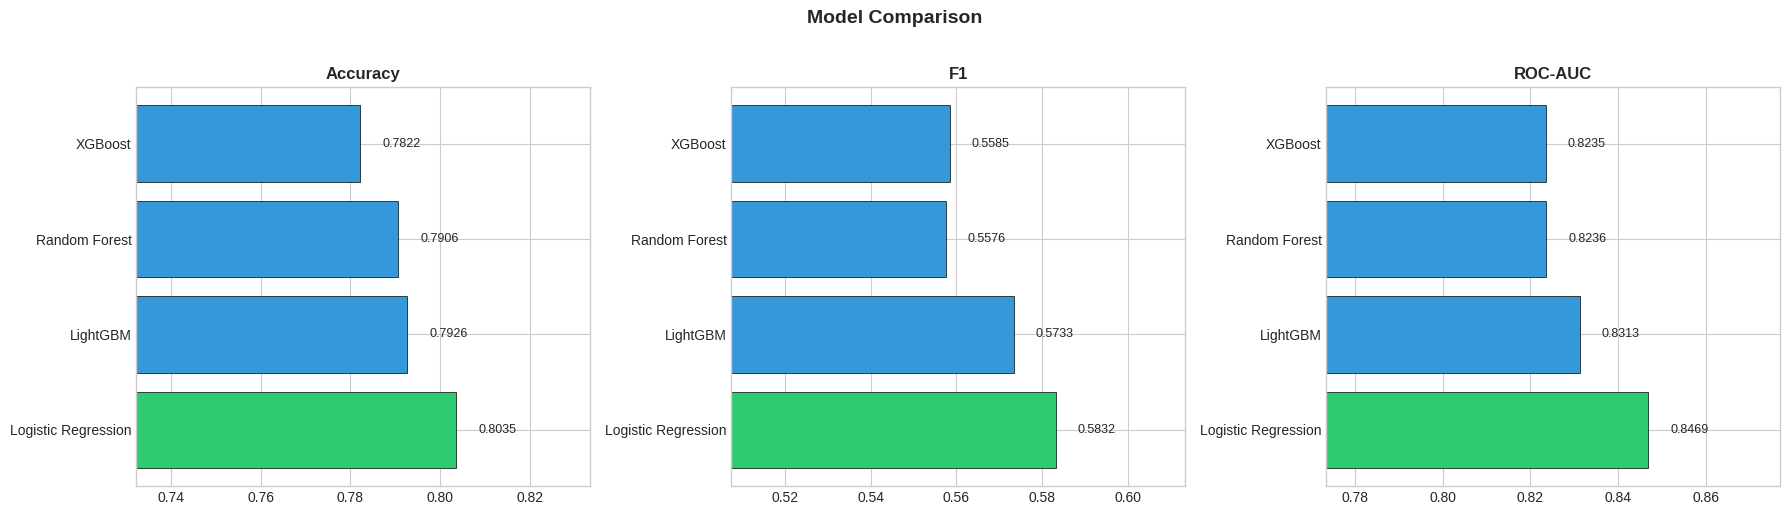

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'auc_mean'], ['Accuracy', 'F1', 'ROC-AUC']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis & Threshold Tuning

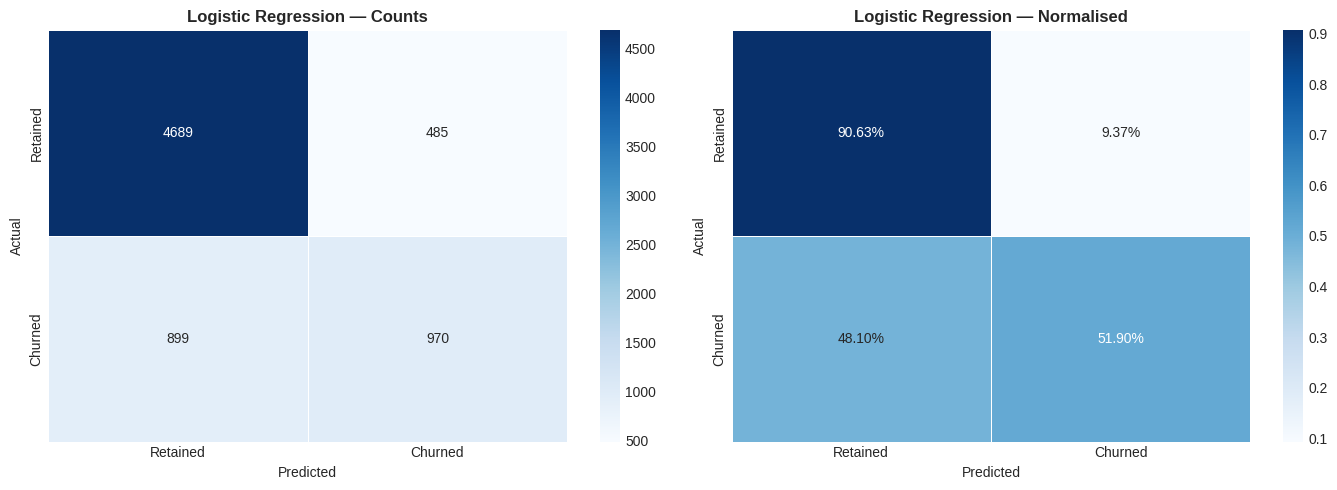


              precision    recall  f1-score   support

    Retained       0.84      0.91      0.87      5174
     Churned       0.67      0.52      0.58      1869

    accuracy                           0.80      7043
   macro avg       0.75      0.71      0.73      7043
weighted avg       0.79      0.80      0.80      7043



In [15]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['Retained', 'Churned']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=cm_labels)}")


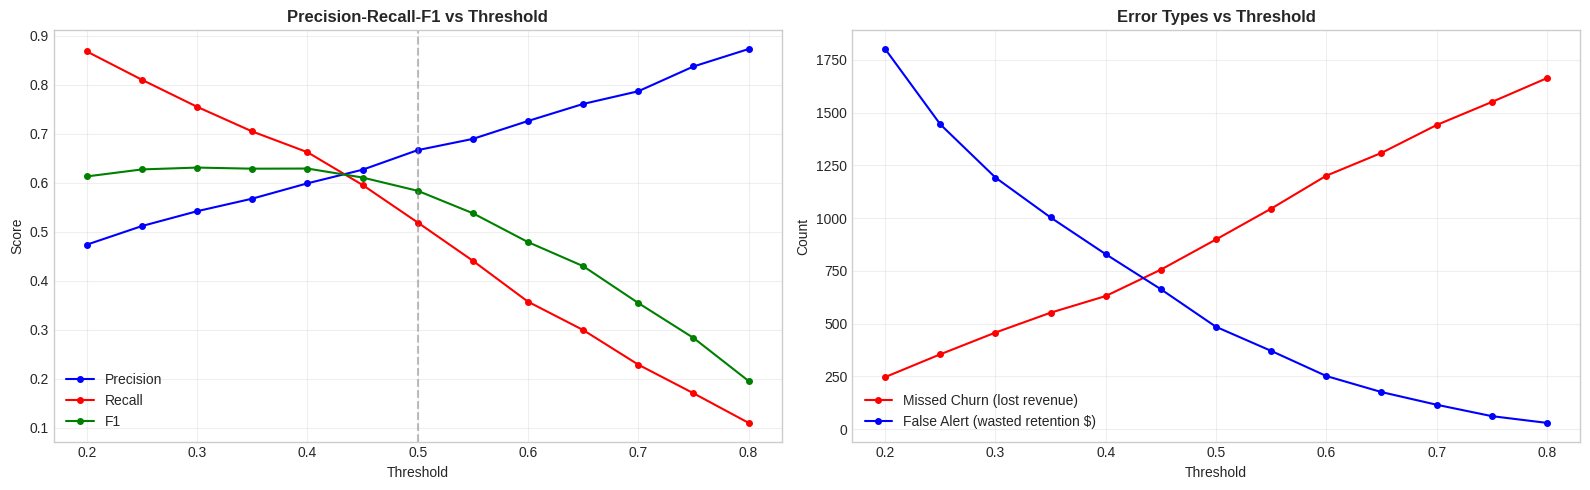


Optimal threshold (F1): 0.30


In [16]:
thresholds = np.arange(0.20, 0.80, 0.05)
thresh_results = []
for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    thresh_results.append({'Threshold': thresh,
        'Precision': precision_score(y, y_t, zero_division=0),
        'Recall': recall_score(y, y_t, zero_division=0),
        'F1': f1_score(y, y_t, zero_division=0),
        'Missed Churn (FN)': ((y == 1) & (y_t == 0)).sum(),
        'False Alert (FP)': ((y == 0) & (y_t == 1)).sum()})
thresh_df = pd.DataFrame(thresh_results)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', ms=4, label='Precision')
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', ms=4, label='Recall')
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', ms=4, label='F1')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(thresh_df['Threshold'], thresh_df['Missed Churn (FN)'], 'r-o', ms=4, label='Missed Churn (lost revenue)')
axes[1].plot(thresh_df['Threshold'], thresh_df['False Alert (FP)'], 'b-o', ms=4, label='False Alert (wasted retention $)')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Types vs Threshold', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight'); plt.show()
best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")


## 8. Feature Importance & Policy Insights

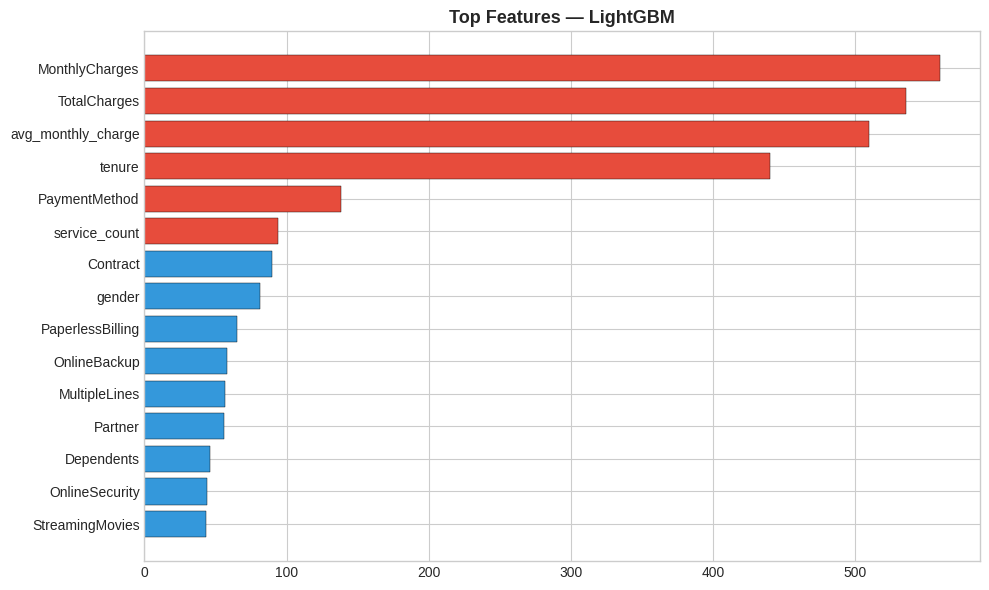

TOP 5 CHURN PREDICTORS
  MonthlyCharges             560.0000
  TotalCharges               536.0000
  avg_monthly_charge         510.0000
  tenure                     440.0000
  PaymentMethod              138.0000

Policy insight: Contract type and tenure are key — month-to-month customers churn more.
ACCC monitors lock-in contracts and switching barriers as competition issues.


In [17]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    plot_imp = feat_imp.tail(15)
    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_imp) * 0.4)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in plot_imp['Importance']]
    ax.barh(plot_imp['Feature'], plot_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Top Features — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 CHURN PREDICTORS")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:25s}  {row['Importance']:.4f}")
    print("\nPolicy insight: Contract type and tenure are key — month-to-month customers churn more.")
    print("ACCC monitors lock-in contracts and switching barriers as competition issues.")


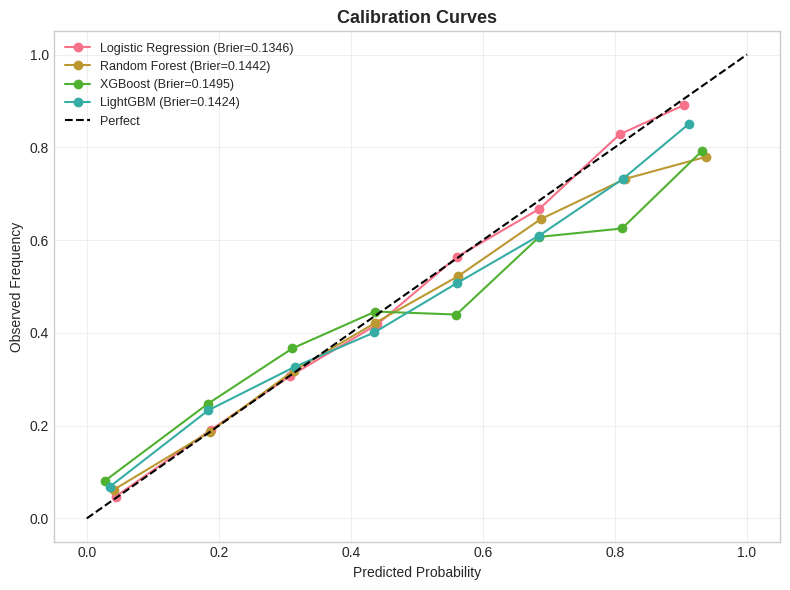

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
for mn in results:
    prob_true, prob_pred = calibration_curve(y, results[mn]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{mn} (Brier={results[mn]['brier_mean']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight'); plt.show()


## 9. Deployment Readiness & Production Considerations

In [19]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print("=" * 60)
checks = {
    'AUC > 0.80': best_res['auc_mean'] > 0.80,
    'F1 > 0.55': best_res['f1_mean'] > 0.55,
    'Brier < 0.15': best_res['brier_mean'] < 0.15,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Threshold tuning done': True,
    'Calibration assessed': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Logistic Regression
  ROC-AUC:              0.8469
  F1:                   0.5832
  Precision:            0.6669
  Recall:               0.5190
  Brier Score:          0.1346
  Training time:        4.4s
  Feature count:        23
  Dataset rows:         7,043
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.30

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.80
  [pass] F1 > 0.55
  [pass] Brier < 0.15
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Threshold tuning done
  [pass] Calibration assessed
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [20]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: CRM system, billing platform, network usage logs, TIO complaints
   Ingestion: API -> Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (usage, billing, service, interactions)
   Schedule: Daily batch + real-time triggers (complaint, downgrade request)

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time at customer interaction + daily batch scoring
   Output: Churn probability + top churn drivers + retention recommendation
   Dashboard: Power BI (churn heatmap by segment, region, plan type)

3. INTEGRATION POINTS
   CRM: Churn risk score on customer profile
   Call centre: Risk flag for inbound calls, retention script trigger
   Marketing: Targeted retention campaigns for high-risk segments
   Product: Feature usage analytics to identify pain points
   ACCC reporting: Aggregate churn analytics for competition monitoring

4. GOVERNANCE
   Privacy: Customer data under Privacy Act 1988, APPs compliance
   Consent: Marketing consent per Spam Act 2003 and Do Not Call Register
   Fairness: Monitor for discrimination in retention offer targeting
   OAIC: Data handling compliant with telecom-specific privacy rules
   ACCC: Churn analytics shared for market competition assessment

5. MONITORING & RETRAINING
   Drift: PSI on usage/billing features monthly
   Performance: AUC on confirmed churn outcomes quarterly
   Retraining: Monthly with rolling 12-month window
   Market events: Recalibrate after competitor launches/price changes
   Regulatory: Adjust for new ACMA consumer safeguard rules

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: CRM system, billing platform, network usage logs, TIO complaints
   Ingestion: API -> Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (usage, billing, service, interactions)
   Schedule: Daily batch + real-time triggers (complaint, downgrade request)

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time at customer interaction + daily batch scoring
   Output: Churn probability + top churn drivers + retention recommendation
   Dashboard: Power BI (churn heatmap by segment, region, plan type)

3. INTEGRATION POINTS
   CRM: Churn risk score on customer profile
   Call centre: Risk flag for inbound calls, retention script trigger
   Marketing: Targeted retention campaigns for high-risk segments
   Product: Feature usage analytics to identify pain points
   ACCC reporting: Aggregate churn analytics for competition monitoring

4. GOVERNANCE
   Privacy: Customer data u